['Nordost' 'Grossraum Ziller' 'Zentralbereich' 'Engadin']
Nordost: BBOX = [ 688675.0001 5239325.      749975.     5286925.    ]
Grossraum Ziller: BBOX = [ 676275.0001 5205325.      738375.0001 5260925.    ]
Zentralbereich: BBOX = [ 583375. 5180625.  701875. 5249625.]
Engadin: BBOX = [ 550975. 5131625.  613475. 5198125.]


c:\Users\Moritz\miniforge3\envs\Masterarbeit\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 203120000 of field Shape_Area of feature 0 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\Moritz\miniforge3\envs\Masterarbeit\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 116920000 of field Shape_Area of feature 1 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\Moritz\miniforge3\envs\Masterarbeit\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 125130000 of field Shape_Area of feature 3 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\Users\Moritz\miniforge3\envs\Masterarbeit\lib\site-packages\pyogrio\raw.py:723: RuntimeWarning: Value 321590000 of field Shape_Area of feature 4 not successfully written. Possibly due to too larger number with respect to field width
  ogr_write(
c:\U

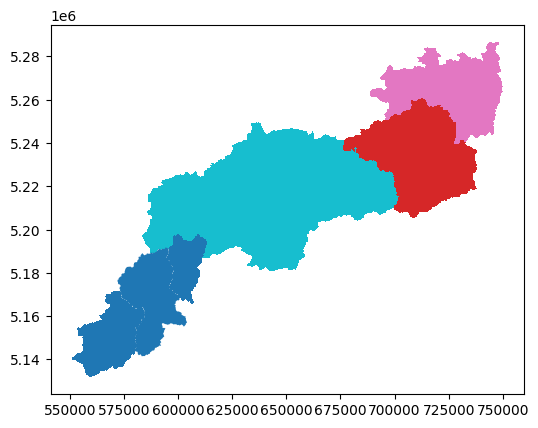

In [17]:
import geopandas as gpd
import os

# Define the path to the shapefile
shapefile_path = r"C:\Users\Moritz\Documents\Uni\Masterarbeit\YETI_MA\Masterarbeit\data\shapefiles\Hopi_basins_20200924.shp"

# Load the shapefile
ses_basins_gdf = gpd.read_file(shapefile_path)

# Print all unique HoPI_Basin values
print(ses_basins_gdf["Großregio"].unique())

# Optional: Plot it to verify
ses_basins_gdf.plot("Großregio")


output_dir = os.path.join(os.path.dirname(shapefile_path), "HOPI_Grossregio")
os.makedirs(output_dir, exist_ok=True)

# Get unique regions
grossregios = ses_basins_gdf["Großregio"].unique()

# Loop through and save each subset
for region in grossregios:
    # Filter GeoDataFrame
    region_gdf = ses_basins_gdf[ses_basins_gdf["Großregio"] == region]

    # Create safe filename (replace spaces, umlauts if needed)
    filename = f"{region.replace(' ', '_')}.shp"
    filepath = os.path.join(output_dir, filename)

    # Save shapefile
    region_gdf.to_file(filepath)

    # Print bounding box
    bounds = region_gdf.total_bounds  # [minx, miny, maxx, maxy]
    print(f"{region}: BBOX = {bounds}")